## Global Airports Dataset - EDA 

This notebook cleans and validates the [raw Kaggle Global Airports dataset]((https://www.kaggle.com/datasets/samvelkoch/global-airports-iata-icao-timezone-geo?resource=download&select=airports.csv)) before it is fused with other sources (e.g. Wikidata). It checks for missing values, validates value ranges for the geo-coordinates and UTC offsets, removes rows with duplicated/stale ICAO codes, and profiles how often rows sharing the same `AirportName` disagree on other columns. 

The cleaned dataset is exported to `data/interim/airports-kaggle.csv` for use in later integration steps.


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

RAW_DIR = project_root / "data" / "raw" / "kaggle"

data = pd.read_csv(RAW_DIR / "airports-kaggle.csv")


## Overview

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6393 entries, 0 to 6392
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AirportName         6393 non-null   str    
 1   IATA                6373 non-null   str    
 2   ICAO                5091 non-null   str    
 3   TimeZone            6305 non-null   str    
 4   City_Name           6393 non-null   str    
 5   City_IATA           6331 non-null   str    
 6   UTC_Offset_Hours    6305 non-null   float64
 7   UTC_Offset_Seconds  6305 non-null   float64
 8   Country_CodeA2      6379 non-null   str    
 9   Country_CodeA3      6393 non-null   str    
 10  Country_Name        6393 non-null   str    
 11  GeoPointLat         6393 non-null   float64
 12  GeoPointLong        6393 non-null   float64
dtypes: float64(4), str(9)
memory usage: 649.4 KB


In [6]:
data.head()

,AirportName,IATA,ICAO,TimeZone,City_Name,City_IATA,UTC_Offset_Hours,UTC_Offset_Seconds,Country_CodeA2,Country_CodeA3,Country_Name,GeoPointLat,GeoPointLong
0,Pilanesberg Intl,NTY,FAPN,Africa/Johannesburg,Sun City,NTY,2.0,7200.0,ZA,ZAF,South Africa,-25.333822,27.173358
1,Clovis Muni,CVN,KCVN,America/Denver,"Clovis, New Mexico",CVN,-6.0,-21600.0,US,USA,United States of America,34.425139,-103.079278
2,Cannon Afb,CVS,KCVS,America/Denver,"Clovis, New Mexico",CVN,-6.0,-21600.0,US,USA,United States of America,34.382775,-103.322147
3,Scammon Bay Airport,SCM,PACM,America/Nome,"Scammon Bay, Alaska",SCM,-8.0,-28800.0,US,USA,United States of America,61.845278,-165.571389
4,Kapit,KPI,NaN,Asia/Kuching,Kapit,KPI,8.0,28800.0,MY,MYS,Malaysia,2.017000,112.950000


## Missingness

In [7]:
total_entries = data.shape[0]
(data.isna().sum() *100 / total_entries).round(2).rename("missing_%")

AirportName            0.00
IATA                   0.31
ICAO                  20.37
TimeZone               1.38
City_Name              0.00
City_IATA              0.97
UTC_Offset_Hours       1.38
UTC_Offset_Seconds     1.38
Country_CodeA2         0.22
Country_CodeA3         0.00
Country_Name           0.00
GeoPointLat            0.00
GeoPointLong           0.00
Name: missing_%, dtype: float64

## GeoPointLat / GeoPointLong Validation


In [8]:
lat, lon = data["GeoPointLat"], data["GeoPointLong"]

n_total = len(data)
n_null = lat.isna().sum() + lon.isna().sum()
n_lat_oob = ((lat < -90) | (lat > 90)).sum()
n_lon_oob = ((lon < -180) | (lon > 180)).sum()
n_null_island = ((lat == 0) & (lon == 0)).sum()
n_dup_pairs = data.duplicated(subset=["GeoPointLat", "GeoPointLong"]).sum()

print(f"Total rows: {n_total}")
print(f"Missing lat/lon values: {n_null}")
print(f"Lat out of [-90, 90]: {n_lat_oob}")
print(f"Lon out of [-180, 180]: {n_lon_oob}")
print(f"Rows at (0, 0) 'Null Island': {n_null_island} ({n_null_island / n_total:.1%})")
print(f"Exact duplicate coordinate pairs: {n_dup_pairs}")


Total rows: 6393
Missing lat/lon values: 0
Lat out of [-90, 90]: 0
Lon out of [-180, 180]: 0
Rows at (0, 0) 'Null Island': 319 (5.0%)
Exact duplicate coordinate pairs: 332


Both columns are complete (no missing values) and every value sits within its valid range ([-90, 90] for latitude, [-180, 180] for longitude), so there are no out-of-range coordinates to fix. However, **319 rows (5.0%) sit exactly at (0, 0)** — "Null Island" — which is a common placeholder for a missing coordinate rather than a real location, so these should be treated as effectively missing in downstream use.


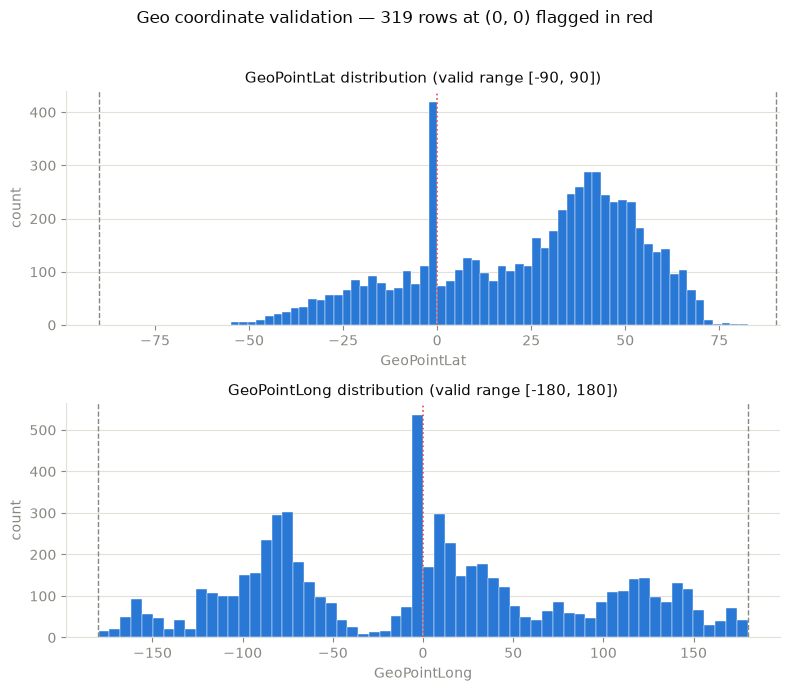

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=False)

bar_color = "#2a78d6"
flag_color = "#e34948"
grid_color = "#e1e0d9"
muted = "#898781"
ink = "#0b0b0b"

specs = [
    (axes[0], lat, "GeoPointLat", -90, 90),
    (axes[1], lon, "GeoPointLong", -180, 180),
]

for ax, series, name, lo, hi in specs:
    ax.hist(series, bins=60, color=bar_color, edgecolor="white", linewidth=0.3)
    ax.axvline(lo, color=muted, linestyle="--", linewidth=1)
    ax.axvline(hi, color=muted, linestyle="--", linewidth=1)
    ax.axvline(0, color=flag_color, linestyle=":", linewidth=1.2)
    ax.set_title(f"{name} distribution (valid range [{lo}, {hi}])", color=ink, fontsize=11)
    ax.set_xlabel(name, color=muted)
    ax.set_ylabel("count", color=muted)
    ax.grid(axis="y", color=grid_color, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(grid_color)
    ax.tick_params(colors=muted)

fig.suptitle(
    f"Geo coordinate validation — {n_null_island} rows at (0, 0) flagged in red",
    color=ink,
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## ICAO Validation

- check for duplicated ICAO codes


In [10]:
data_na_icao = data.loc[:, ["ICAO"]].isnull() == False

print("Duplicated Airport Name:", data.loc[:,["ICAO"]][data_na_icao].duplicated().sum())

Duplicated Airport Name: 1303


In [11]:
data_na_icao = data[data["ICAO"].notna()]
icao_dup = data_na_icao["ICAO"].duplicated(keep=False)

print("Duplicated ICAO values:", data_na_icao.loc[icao_dup, "ICAO"].nunique())
print("Rows involved:", icao_dup.sum())
data_na_icao.loc[icao_dup, ["AirportName", "IATA", "ICAO", "City_Name", "Country_Name"]].sort_values("ICAO")

Duplicated ICAO values: 2
Rows involved: 4


,AirportName,IATA,ICAO,City_Name,Country_Name
5766,Schonefeld,SXF,EDDB,Berlin,Germany
5767,Berlin Brandenburg Willy Brandt,BER,EDDB,Berlin,Germany
4096,Dortmund,DTM,EDLW,Dortmund,Germany
4097,HBF RAILWAY STATION,DTZ,EDLW,Dortmund,Germany


In [12]:
# Remove duplicated ICAO entries: old Berlin Schonefeld (merged into BER) and Dortmund railway station
drop_mask = ((data["ICAO"] == "EDDB") & (data["AirportName"] == "Schonefeld")) | \
            ((data["ICAO"] == "EDLW") & (data["AirportName"] == "HBF RAILWAY STATION"))

print("Rows removed:", drop_mask.sum())
data = data[~drop_mask].reset_index(drop=True)
print("Remaining rows:", data.shape[0])

Rows removed: 2
Remaining rows: 6391


### Duplicated ICAO



| Index | AirportName | IATA | ICAO | City_Name | Country_Name |
|---|---|---|---|---|---|
| 5766 | Schonefeld | SXF | EDDB | Berlin | Germany |
| 5767 | Berlin Brandenburg Willy Brandt | BER | EDDB | Berlin | Germany |
| 4096 | Dortmund | DTM | EDLW | Dortmund | Germany |
| 4097 | HBF RAILWAY STATION | DTZ | EDLW | Dortmund | Germany |

- **Row 5766 (Schonefeld, SXF)** is dropped: it is the old Berlin airport, since merged into Berlin Brandenburg Willy Brandt (BER), which now uses the shared ICAO `EDDB`.
- **Row 4097 (HBF RAILWAY STATION, DTZ)** is dropped: it is a railway station, not an airport, and it reuses the ICAO of the nearby Dortmund airport (`EDLW`).


## UTC_Offset_Hours / UTC_Offset_Seconds Validation


In [13]:
hours, seconds = data["UTC_Offset_Hours"], data["UTC_Offset_Seconds"]

n_total = len(data)
n_null_hours = hours.isna().sum()
n_null_seconds = seconds.isna().sum()
n_hours_oob = ((hours < -12) | (hours > 14)).sum()
n_seconds_oob = ((seconds < -12 * 3600) | (seconds > 14 * 3600)).sum()
n_mismatch = ((hours * 3600 - seconds).abs() > 1).sum()

print(f"Total rows: {n_total}")
print(f"Missing UTC_Offset_Hours: {n_null_hours} ({n_null_hours / n_total:.1%})")
print(f"Missing UTC_Offset_Seconds: {n_null_seconds} ({n_null_seconds / n_total:.1%})")
print(f"Hours out of real-world range [-12, 14]: {n_hours_oob}")
print(f"Seconds out of real-world range [-43200, 50400]: {n_seconds_oob}")
print(f"Hours/seconds inconsistent (hours * 3600 != seconds): {n_mismatch}")


Total rows: 6391
Missing UTC_Offset_Hours: 88 (1.4%)
Missing UTC_Offset_Seconds: 88 (1.4%)
Hours out of real-world range [-12, 14]: 0
Seconds out of real-world range [-43200, 50400]: 0
Hours/seconds inconsistent (hours * 3600 != seconds): 0


Both columns fall within the real-world UTC offset range ([-12, +14] hours) with no out-of-range values, and `UTC_Offset_Seconds` is fully consistent with `UTC_Offset_Hours` (always equal to `hours * 3600`). The only issue is **88 rows (1.4%) missing both values together** — a shared gap rather than a range or consistency problem.


/var/folders/1b/jxsrmkz17_qc4wdf17nykhbw0000gn/T/ipykernel_7538/3224663752.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/1b/jxsrmkz17_qc4wdf17nykhbw0000gn/T/ipykernel_7538/3224663752.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(


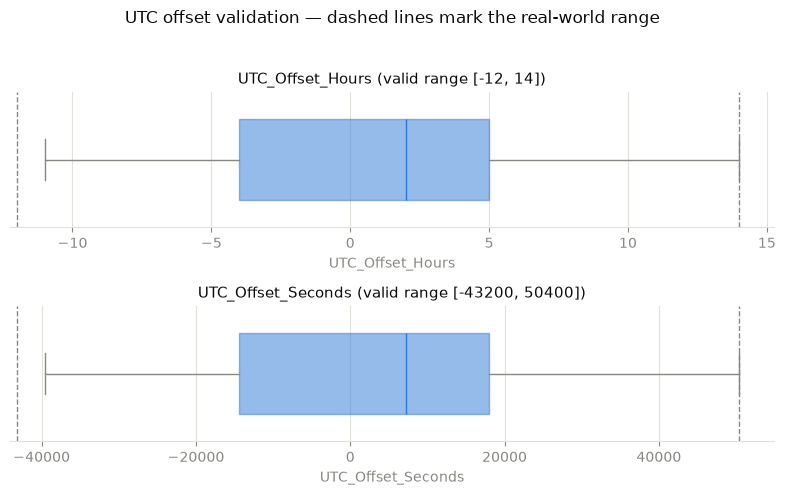

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5))

box_color = "#2a78d6"
flag_color = "#898781"
grid_color = "#e1e0d9"
muted = "#898781"
ink = "#0b0b0b"

specs = [
    (axes[0], hours.dropna(), "UTC_Offset_Hours", -12, 14),
    (axes[1], seconds.dropna(), "UTC_Offset_Seconds", -12 * 3600, 14 * 3600),
]

for ax, series, name, lo, hi in specs:
    bp = ax.boxplot(
        series,
        vert=False,
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor=box_color, edgecolor=box_color, alpha=0.5),
        medianprops=dict(color=box_color),
        whiskerprops=dict(color=muted),
        capprops=dict(color=muted),
        flierprops=dict(markeredgecolor=muted, markersize=4),
    )
    ax.axvline(lo, color=flag_color, linestyle="--", linewidth=1)
    ax.axvline(hi, color=flag_color, linestyle="--", linewidth=1)
    ax.set_title(f"{name} (valid range [{lo}, {hi}])", color=ink, fontsize=11)
    ax.set_xlabel(name, color=muted)
    ax.set_yticks([])
    ax.grid(axis="x", color=grid_color, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(grid_color)
    ax.tick_params(colors=muted)

fig.suptitle("UTC offset validation — dashed lines mark the real-world range", color=ink, fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Conflicting Rate Calculation

This table shows the conflicting rate of each column — the share of rows where rows sharing the same `AirportName` hold contradictory (non-null, differing) values. Fortunately, all columns stay below 2%.

In [15]:
other_columns = [col for col in data.columns if col != "AirportName"]
name_clean = data["AirportName"].str.strip()  # lstrip+rstrip so trailing/leading whitespace doesn't hide true duplicates

total_rows = len(data)
conflict_rates = {}

for col in other_columns:
    group_nunique = data.groupby(name_clean)[col].transform(lambda s: s.dropna().nunique())
    conflict_rates[col] = (group_nunique >= 2).sum() / total_rows

conflict_rate_df = pd.DataFrame({
    "attribute": list(conflict_rates.keys()),
    "conflicting_rate": list(conflict_rates.values()),
})
conflict_rate_df["conflicting_rate"] = conflict_rate_df["conflicting_rate"].map(lambda x: f"{x:.2%}")
conflict_rate_df

,attribute,conflicting_rate
0,IATA,1.74%
1,ICAO,0.89%
2,TimeZone,1.39%
3,City_Name,1.35%
4,City_IATA,1.64%
5,UTC_Offset_Hours,0.99%
6,UTC_Offset_Seconds,0.99%
7,Country_CodeA2,1.22%
8,Country_CodeA3,1.22%
9,Country_Name,1.22%


In [16]:
conflict_rate_df

,attribute,conflicting_rate
0,IATA,1.74%
1,ICAO,0.89%
2,TimeZone,1.39%
3,City_Name,1.35%
4,City_IATA,1.64%
5,UTC_Offset_Hours,0.99%
6,UTC_Offset_Seconds,0.99%
7,Country_CodeA2,1.22%
8,Country_CodeA3,1.22%
9,Country_Name,1.22%


## Final Dataset

In [17]:
data.head()

,AirportName,IATA,ICAO,TimeZone,City_Name,City_IATA,UTC_Offset_Hours,UTC_Offset_Seconds,Country_CodeA2,Country_CodeA3,Country_Name,GeoPointLat,GeoPointLong
0,Pilanesberg Intl,NTY,FAPN,Africa/Johannesburg,Sun City,NTY,2.0,7200.0,ZA,ZAF,South Africa,-25.333822,27.173358
1,Clovis Muni,CVN,KCVN,America/Denver,"Clovis, New Mexico",CVN,-6.0,-21600.0,US,USA,United States of America,34.425139,-103.079278
2,Cannon Afb,CVS,KCVS,America/Denver,"Clovis, New Mexico",CVN,-6.0,-21600.0,US,USA,United States of America,34.382775,-103.322147
3,Scammon Bay Airport,SCM,PACM,America/Nome,"Scammon Bay, Alaska",SCM,-8.0,-28800.0,US,USA,United States of America,61.845278,-165.571389
4,Kapit,KPI,NaN,Asia/Kuching,Kapit,KPI,8.0,28800.0,MY,MYS,Malaysia,2.017000,112.950000


In [18]:
data.info() # only remove two tuples with duplicated ICAO 

<class 'pandas.DataFrame'>
RangeIndex: 6391 entries, 0 to 6390
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AirportName         6391 non-null   str    
 1   IATA                6371 non-null   str    
 2   ICAO                5089 non-null   str    
 3   TimeZone            6303 non-null   str    
 4   City_Name           6391 non-null   str    
 5   City_IATA           6329 non-null   str    
 6   UTC_Offset_Hours    6303 non-null   float64
 7   UTC_Offset_Seconds  6303 non-null   float64
 8   Country_CodeA2      6377 non-null   str    
 9   Country_CodeA3      6391 non-null   str    
 10  Country_Name        6391 non-null   str    
 11  GeoPointLat         6391 non-null   float64
 12  GeoPointLong        6391 non-null   float64
dtypes: float64(4), str(9)
memory usage: 649.2 KB


In [19]:
INTERIM_DIR = project_root / "data" / "interim"
out_path = INTERIM_DIR / "airports-kaggle.csv"

data.to_csv(out_path, index=False)
print(f"Saved {data.shape[0]} rows, {data.shape[1]} columns to {out_path.relative_to(project_root)}")


Saved 6391 rows, 13 columns to data/interim/airports-kaggle.csv


## Note for Future

After data fusion, we can inspect the rows that share the same AirportName, Longitude, and Latitude in this dataset. However, some of these duplicates actually represent different airports — they simply share the same name and a (0, 0) placeholder for their geo data. We should specifically review these data-fusion results to verify such special cases.


In [20]:
# delete AirportName, CountryName, ICAO, City_Name  duplicated data 
#

duplicated_data = data.loc[:,["AirportName", "Country_Name", "ICAO", "City_Name", "GeoPointLat" , "GeoPointLong"]][data.loc[:,["AirportName", "GeoPointLat" , "GeoPointLong"]].duplicated(keep = False)] # select those with same AirportName, GeoPointLat and GeoPointLong
airport_names_du = duplicated_data.AirportName.unique()


duplicated_data

,AirportName,Country_Name,ICAO,City_Name,GeoPointLat,GeoPointLong
476,Long island,Australia,NaN,Long Island,0.0,0.0
616,BUS STATION,Austria,NaN,Woergl,0.0,0.0
666,RAILWAY STATION,Spain,NaN,Murcia,0.0,0.0
830,HBF RAILWAY STATION,Germany,NaN,Ulm,0.0,0.0
1754,CENTRAL RAILWAY STN,Italy,NaN,Bologna,0.0,0.0
1879,HBF RAILWAY STATION,Germany,NaN,Mannheim,0.0,0.0
1956,RAILWAY STATION,Austria,NaN,Innsbruck,0.0,0.0
2088,VALENCIA RAILWAY STN,Spain,NaN,Valencia,0.0,0.0
2193,BUS STATION,Italy,NaN,Reggio Nell Emilia,0.0,0.0
2820,RAILWAY STATION,Italy,NaN,Trieste,0.0,0.0
